In [1]:
# Import required libraries
!pip install numpy pandas matplotlib scikit-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Generate synthetic customer dataset

np.random.seed(42)

records = 800

Age = np.random.randint(18, 60, records)

Salary = np.random.randint(
    20000, 150000, records
)

Experience = np.random.randint(
    0, 35, records
)

# Creating imbalanced target
# 80% = Not Purchased
# 20% = Purchased

Purchased = np.random.choice(
    [0,1],
    size=records,
    p=[0.8,0.2]
)


df = pd.DataFrame({
    "Age":Age,
    "Salary":Salary,
    "Experience":Experience,
    "Purchased":Purchased
})


df.head()

,Age,Salary,Experience,Purchased
0,56,24621,23,0
1,46,35034,34,0
2,32,131927,33,0
3,25,147858,2,1
4,38,25126,25,0


In [3]:
#Check distribution
df["Purchased"].value_counts()

Purchased
0    639
1    161
Name: count, dtype: int64

# Feature Engineering

In [4]:
df["Salary_per_Experience"] = (
    df["Salary"] /
    (df["Experience"] + 1)
)


df["Age_Bucket"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,60],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46+"
    ]
)


df["Age_Salary_Interaction"] = (
    df["Age"] * df["Salary"]
)


df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experience,Age_Bucket,Age_Salary_Interaction
0,56,24621,23,0,1025.875000,46+,1378776
1,46,35034,34,0,1000.971429,46+,1611564
2,32,131927,33,0,3880.205882,26-35,4221664
3,25,147858,2,1,49286.000000,18-25,3696450
4,38,25126,25,0,966.384615,36-45,954788


# Compare One Hot Encoding and Label Encoding

In [5]:
label_df=df.copy()

encoder = LabelEncoder()

label_df["Age_Bucket"] = (
    encoder.fit_transform(
        label_df["Age_Bucket"]
    )
)

label_df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experience,Age_Bucket,Age_Salary_Interaction
0,56,24621,23,0,1025.875000,3,1378776
1,46,35034,34,0,1000.971429,3,1611564
2,32,131927,33,0,3880.205882,1,4221664
3,25,147858,2,1,49286.000000,0,3696450
4,38,25126,25,0,966.384615,2,954788


In [6]:
# One Hot Encoding
onehot_df = pd.get_dummies(
    df,
    columns=["Age_Bucket"]
)

onehot_df.head()

,Age,Salary,Experience,Purchased,Salary_per_Experience,Age_Salary_Interaction,Age_Bucket_18-25,Age_Bucket_26-35,Age_Bucket_36-45,Age_Bucket_46+
0,56,24621,23,0,1025.875000,1378776,False,False,False,True
1,46,35034,34,0,1000.971429,1611564,False,False,False,True
2,32,131927,33,0,3880.205882,4221664,False,True,False,False
3,25,147858,2,1,49286.000000,3696450,True,False,False,False
4,38,25126,25,0,966.384615,954788,False,False,True,False


In [7]:
# Check features
print(
"Label Encoding Features:",
label_df.shape[1]
)

print(
"One Hot Encoding Features:",
onehot_df.shape[1]
)

Label Encoding Features: 7
One Hot Encoding Features: 10


# Detect Salary Outliers using IQR

In [8]:
Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1


lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR


outliers = df[
    (df["Salary"]<lower) |
    (df["Salary"]>upper)
]


print(
"Number of outliers:",
len(outliers)
)

Number of outliers: 0


In [9]:
# Remove outliers:
clean_df = df[
    (df["Salary"]>=lower) &
    (df["Salary"]<=upper)
]

clean_df.shape

(800, 7)

# Multicollinearity using Correlation and VIF

In [10]:
# Install
!pip install statsmodels

In [11]:
# Correlation
features = df[
[
"Age",
"Salary",
"Experience",
"Salary_per_Experience",
"Age_Salary_Interaction"
]
]


features.corr()

,Age,Salary,Experience,Salary_per_Experience,Age_Salary_Interaction
Age,1.000000,0.035468,-0.039819,-0.018115,0.567521
Salary,0.035468,1.000000,0.027707,0.249598,0.806150
Experience,-0.039819,0.027707,1.000000,-0.577672,-0.005498
Salary_per_Experience,-0.018115,0.249598,-0.577672,1.000000,0.187241
Age_Salary_Interaction,0.567521,0.806150,-0.005498,0.187241,1.000000


In [12]:
# VIF Calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor


vif = pd.DataFrame()

vif["Feature"] = features.columns


vif["VIF"] = [
variance_inflation_factor(
features.values,i
)

for i in range(
features.shape[1]
)
]


vif

,Feature,VIF
0,Age,9.816027
1,Salary,19.064371
2,Experience,5.597593
3,Salary_per_Experience,2.341086
4,Age_Salary_Interaction,20.490295


In [13]:
# Use Stratified Train-Test Split
# Separating input and output

X = onehot_df.drop("Purchased", axis=1)

y = onehot_df["Purchased"]


# Stratified train test split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training distribution:")
print(y_train.value_counts())


print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
Purchased
0    511
1    129
Name: count, dtype: int64

Testing distribution:
Purchased
0    128
1     32
Name: count, dtype: int64


In [14]:
# Compare Scaling Strategies
standard = StandardScaler()

X_train_standard = standard.fit_transform(X_train)

X_test_standard = standard.transform(X_test)

In [15]:
# MinMaxScaler
minmax = MinMaxScaler()

X_train_minmax = minmax.fit_transform(X_train)

X_test_minmax = minmax.transform(X_test)

In [16]:
# ANN Function
def create_ann():

    model = Sequential()

    model.add(
        Dense(
            16,
            activation="relu",
            input_shape=(X_train.shape[1],)
        )
    )

    model.add(
        Dense(
            8,
            activation="relu"
        )
    )

    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )


    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )


    return model

In [17]:
# Train StandardScaler Model
model_standard = create_ann()


history_standard = model_standard.fit(
    
    X_train_standard,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

In [18]:
# Train MinMaxScaler Model
model_minmax = create_ann()


history_minmax = model_minmax.fit(

    X_train_minmax,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

In [19]:
# Compare Accuracy
print(
"StandardScaler Accuracy:",
history_standard.history["val_accuracy"][-1]
)


print(
"MinMaxScaler Accuracy:",
history_minmax.history["val_accuracy"][-1]
)

StandardScaler Accuracy: 0.796875
MinMaxScaler Accuracy: 0.796875


In [20]:
# Handle Class Imbalance
# Method 1: Class Weight
from sklearn.utils import class_weight


weights = class_weight.compute_class_weight(

    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)


weights = dict(
    enumerate(weights)
)


weights

{0: np.float64(0.6262230919765166), 1: np.float64(2.4806201550387597)}

In [21]:
# Train:
weighted_model=create_ann()


weighted_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    class_weight=weights,
    verbose=0

)

In [22]:
# Method 2: SMOTE Oversampling
!pip install imbalanced-learn

In [23]:
from imblearn.over_sampling import SMOTE


sm = SMOTE(
    random_state=42
)


X_smote, y_smote = sm.fit_resample(

    X_train_standard,
    y_train

)


print(y_smote.value_counts())

Purchased
0    511
1    511
Name: count, dtype: int64


In [24]:
# Train:
smote_model=create_ann()


smote_model.fit(

    X_smote,
    y_smote,
    epochs=50,
    verbose=0

)

In [25]:
# Compare Precision Recall F1
from sklearn.metrics import classification_report


pred = smote_model.predict(
    X_test_standard
)


pred = (pred>0.5).astype(int)


print(
classification_report(
    y_test,
    pred
)
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
              precision    recall  f1-score   support

           0       0.82      0.62      0.71       128
           1       0.23      0.47      0.31        32

    accuracy                           0.59       160
   macro avg       0.53      0.54      0.51       160
weighted avg       0.71      0.59      0.63       160



In [26]:
# Create Train / Validation / Test Split
# First split train and temporary data

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y

)


# Split temporary into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp

)


print(X_train.shape)

print(X_val.shape)

print(X_test.shape)

(560, 9)
(120, 9)
(120, 9)


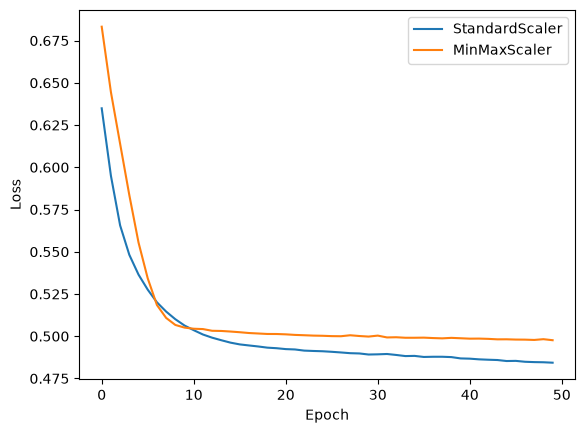

In [27]:
# Explain Scaling Effect using Loss Curves
plt.plot(
history_standard.history["loss"],
label="StandardScaler"
)


plt.plot(
history_minmax.history["loss"],
label="MinMaxScaler"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [28]:
# Rebuild ANN using Keras Functional API
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model


# Input Layer
inputs = Input(
    shape=(X_train_standard.shape[1],)
)


# Hidden Layers
x = Dense(
    16,
    activation="relu"
)(inputs)


x = Dense(
    8,
    activation="relu"
)(x)


# Output Layer
outputs = Dense(
    1,
    activation="sigmoid"
)(x)



functional_model = Model(
    inputs=inputs,
    outputs=outputs
)


functional_model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)


functional_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Scale again after Q9 split

scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train)

X_val_standard = scaler.transform(X_val)

X_test_standard = scaler.transform(X_test)

In [30]:
functional_history = functional_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_data=(X_val_standard, y_val)

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6589 - loss: 0.6363 - val_accuracy: 0.7167 - val_loss: 0.6042
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7643 - loss: 0.5897 - val_accuracy: 0.7750 - val_loss: 0.5748
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7875 - loss: 0.5622 - val_accuracy: 0.7917 - val_loss: 0.5573
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5414 - val_accuracy: 0.8000 - val_loss: 0.5491
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5318 - val_accuracy: 0.8000 - val_loss: 0.5443
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7982 - loss: 0.5249 - val_accuracy: 0.8000 - val_loss: 0.5391
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7982 - loss: 0.5206 - val_accuracy: 0.8000 - val_loss: 0.5348
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.5166 - val_accuracy: 0.8000 - v

In [31]:
# Prediction
predictions = functional_model.predict(
    X_test_standard
)

predictions[:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[0.2287103 ],
       [0.16246864],
       [0.1363935 ],
       [0.17074466],
       [0.17250979]], dtype=float32)

In [32]:
# Add Dropout Regularization
from tensorflow.keras.layers import Dropout

In [33]:
# ANN with Dropout
dropout_model = Sequential()


dropout_model.add(
    Dense(
        16,
        activation="relu",
        input_shape=(X_train_standard.shape[1],)
    )
)


dropout_model.add(
    Dropout(0.2)
)


dropout_model.add(
    Dense(
        8,
        activation="relu"
    )
)


dropout_model.add(
    Dropout(0.2)
)


dropout_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)


dropout_model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)

In [34]:
# Train
drop_history = dropout_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_split=0.2

)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7188 - loss: 0.6190 - val_accuracy: 0.6786 - val_loss: 0.6093
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7054 - loss: 0.6186 - val_accuracy: 0.7321 - val_loss: 0.5880
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7232 - loss: 0.5834 - val_accuracy: 0.7411 - val_loss: 0.5748
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7321 - loss: 0.5890 - val_accuracy: 0.7500 - val_loss: 0.5630
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7500 - loss: 0.5643 - val_accuracy: 0.7500 - val_loss: 0.5537
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7545 - loss: 0.5548 - val_accuracy: 0.7500 - val_loss: 0.5471
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7723 - loss: 0.5625 - val_accuracy: 0.7679 - val_loss: 0.5417
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7634 - loss: 0.5555 - val_accuracy: 0.7946 - v

In [35]:
# Compare Accuracy
print(
"Training Accuracy:",
drop_history.history["accuracy"][-1]
)


print(
"Validation Accuracy:",
drop_history.history["val_accuracy"][-1]
)

Training Accuracy: 0.8013392686843872
Validation Accuracy: 0.7857142686843872


In [36]:
# Add Batch Normalization
from tensorflow.keras.layers import BatchNormalization

In [37]:
batch_model = Sequential([


Dense(
    16,
    input_shape=(X_train_standard.shape[1],)
),


BatchNormalization(),


tf.keras.layers.Activation("relu"),


Dense(8),


BatchNormalization(),


tf.keras.layers.Activation("relu"),


Dense(
    1,
    activation="sigmoid"
)

])


batch_model.compile(

optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]

)

In [38]:
# Train
batch_history=batch_model.fit(

X_train_standard,
y_train,
epochs=50,
validation_split=0.2

)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5513 - loss: 0.6627 - val_accuracy: 0.5268 - val_loss: 0.6788
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6763 - loss: 0.6271 - val_accuracy: 0.5625 - val_loss: 0.6587
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7344 - loss: 0.6048 - val_accuracy: 0.6250 - val_loss: 0.6396
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7746 - loss: 0.5763 - val_accuracy: 0.6786 - val_loss: 0.6206
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7902 - loss: 0.5606 - val_accuracy: 0.7054 - val_loss: 0.6060
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8036 - loss: 0.5554 - val_accuracy: 0.7143 - val_loss: 0.5923
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8036 - loss: 0.5349 - val_accuracy: 0.7232 - val_loss: 0.5803
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8080 - loss: 0.5301 - val_accuracy: 0.7589 - v

In [39]:
# Compare Weight Initialization Strategies
initializers = [

"he_normal",
"glorot_uniform",
"random_normal"

]


results = {}


for init in initializers:


    model = Sequential([


    Dense(
        16,
        activation="relu",
        kernel_initializer=init,
        input_shape=(X_train_standard.shape[1],)
    ),


    Dense(
        8,
        activation="relu",
        kernel_initializer=init
    ),


    Dense(
        1,
        activation="sigmoid"
    )

    ])


    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )


    h=model.fit(
        X_train_standard,
        y_train,
        epochs=10,
        verbose=0
    )


    results[init]=h.history["loss"][-1]


results

{'he_normal': 0.5071309208869934,
 'glorot_uniform': 0.4999092221260071,
 'random_normal': 0.49558067321777344}

In [40]:
# Build Deep Funnel ANN
funnel_model = Sequential([


Dense(
16,
activation="relu",
input_shape=(X_train_standard.shape[1],)
),


Dense(
8,
activation="relu"
),


Dense(
4,
activation="relu"
),


Dense(
2,
activation="relu"
),


Dense(
1,
activation="sigmoid"
)

])


funnel_model.compile(

optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]

)


funnel_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345 (1.35 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train
funnel_history=funnel_model.fit(

X_train_standard,
y_train,
epochs=50,
validation_split=0.2

)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4911 - loss: 0.7125 - val_accuracy: 0.6607 - val_loss: 0.7038
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6719 - loss: 0.6945 - val_accuracy: 0.7411 - val_loss: 0.6931
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7723 - loss: 0.6853 - val_accuracy: 0.7500 - val_loss: 0.6864
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7924 - loss: 0.6802 - val_accuracy: 0.7768 - val_loss: 0.6805
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7991 - loss: 0.6759 - val_accuracy: 0.7768 - val_loss: 0.6762
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7991 - loss: 0.6719 - val_accuracy: 0.7768 - val_loss: 0.6724
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8013 - loss: 0.6682 - val_accuracy: 0.7768 - val_loss: 0.6689
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8013 - loss: 0.6646 - val_accuracy: 0.7768 - v

In [42]:
# Check Weights
for layer in funnel_model.layers:

    print(
        layer.name,
        np.mean(layer.get_weights()[0])
    )

dense_30 0.017358925
dense_31 0.009344414
dense_32 -0.068859205
dense_33 0.31288972
dense_34 0.25231197


In [43]:
# Implement Custom Activation Function
import tensorflow.keras.backend as K


def scaled_tanh(x):

    return 1.5 * K.tanh(x)

In [44]:
# Use Custom Activation
custom_model = Sequential([


Dense(
16,
activation=scaled_tanh,
input_shape=(X_train_standard.shape[1],)
),


Dense(
8,
activation="relu"
),


Dense(
1,
activation="sigmoid"
)


])


custom_model.compile(

optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]

)

In [45]:
# Train
custom_model.fit(

X_train_standard,
y_train,
epochs=50

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5321 - loss: 0.7414
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6464 - loss: 0.6531
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7107 - loss: 0.6007 
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7518 - loss: 0.5691 
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7768 - loss: 0.5493
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7929 - loss: 0.5361 
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7964 - loss: 0.5275
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7946 - loss: 0.5193
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7946 - loss: 0.5172 
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7946 - loss: 0.5126 
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7946 - loss: 0.5095 
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.794

In [46]:
# Apply L1 and L2 Regularization
# L1 Regularization Model
from tensorflow.keras.regularizers import l1, l2
l1_model = Sequential([

    Dense(
        16,
        activation="relu",
        kernel_regularizer=l1(0.01),
        input_shape=(X_train_standard.shape[1],)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


l1_model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)


l1_history = l1_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_data=(X_val_standard,y_val)

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6446 - loss: 1.0142 - val_accuracy: 0.7250 - val_loss: 0.9485
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7375 - loss: 0.9412 - val_accuracy: 0.8000 - val_loss: 0.8996
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7929 - loss: 0.8931 - val_accuracy: 0.8000 - val_loss: 0.8689
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.8638 - val_accuracy: 0.8000 - val_loss: 0.8472
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.8407 - val_accuracy: 0.8000 - val_loss: 0.8314
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7982 - loss: 0.8232 - val_accuracy: 0.8000 - val_loss: 0.8172
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.8081 - val_accuracy: 0.8000 - val_loss: 0.8034
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.7938 - val_accuracy: 0.8000 - va

In [47]:
# L2 Regularization Model
l2_model = Sequential([

    Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.01),
        input_shape=(X_train_standard.shape[1],)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])


l2_model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)


l2_history = l2_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_data=(X_val_standard,y_val)

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6804 - loss: 0.7572 - val_accuracy: 0.8000 - val_loss: 0.6929
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7732 - loss: 0.6885 - val_accuracy: 0.8000 - val_loss: 0.6441
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7946 - loss: 0.6490 - val_accuracy: 0.8000 - val_loss: 0.6173
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7964 - loss: 0.6278 - val_accuracy: 0.8000 - val_loss: 0.6027
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.6159 - val_accuracy: 0.8000 - val_loss: 0.5944
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.6082 - val_accuracy: 0.8000 - val_loss: 0.5892
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.6009 - val_accuracy: 0.8000 - val_loss: 0.5848
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7982 - loss: 0.5948 - val_accuracy: 0.8000 - v

In [48]:
# Compare Weight Magnitude
print(
"L1 Weight Mean:",
np.mean(abs(l1_model.layers[0].get_weights()[0]))
)


print(
"L2 Weight Mean:",
np.mean(abs(l2_model.layers[0].get_weights()[0]))
)

L1 Weight Mean: 0.019589592
L2 Weight Mean: 0.08939695


In [49]:
# Implement Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
# Code
early_stop = EarlyStopping(

    monitor="val_loss",
    patience=5,
    restore_best_weights=True

)


early_model=create_ann()


history_early = early_model.fit(

    X_train_standard,
    y_train,
    epochs=100,
    validation_data=(X_val_standard,y_val),
    callbacks=[early_stop]

)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6768 - loss: 0.6350 - val_accuracy: 0.7750 - val_loss: 0.6099
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7804 - loss: 0.5995 - val_accuracy: 0.8000 - val_loss: 0.5728
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.5690 - val_accuracy: 0.8000 - val_loss: 0.5435
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7982 - loss: 0.5435 - val_accuracy: 0.8000 - val_loss: 0.5219
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7982 - loss: 0.5255 - val_accuracy: 0.8000 - val_loss: 0.5051
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7982 - loss: 0.5132 - val_accuracy: 0.8000 - val_loss: 0.4981
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5059 - val_accuracy: 0.8000 - val_loss: 0.4959
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7982 - loss: 0.5023 - val_accuracy: 0.800

In [51]:
# Check Stopped Epoch
print(
"Training stopped at epoch:",
len(history_early.history["loss"])
)

Training stopped at epoch: 12


In [52]:
# ReduceLROnPlateau Learning Rate Scheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [53]:
lr_reduce = ReduceLROnPlateau(

    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1

)


lr_model=create_ann()


lr_history=lr_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_data=(X_val_standard,y_val),
    callbacks=[lr_reduce]

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6607 - loss: 0.6452 - val_accuracy: 0.7083 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7643 - loss: 0.5873 - val_accuracy: 0.7667 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7946 - loss: 0.5503 - val_accuracy: 0.7917 - val_loss: 0.5430 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5270 - val_accuracy: 0.8000 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7982 - loss: 0.5143 - val_accuracy: 0.8000 - val_loss: 0.5151 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7982 - loss: 0.5074 - val_accuracy: 0.8000 - val_loss: 0.5108 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5041 - val_acc

In [54]:
# Custom Exponential Learning Rate Decay
from tensorflow.keras.callbacks import LearningRateScheduler
import math

In [55]:
def exponential_decay(epoch, lr):

    return lr * math.exp(-0.1)


scheduler = LearningRateScheduler(
    exponential_decay
)

In [56]:
decay_model=create_ann()


decay_history=decay_model.fit(

    X_train_standard,
    y_train,
    epochs=50,
    validation_data=(X_val_standard,y_val),
    callbacks=[scheduler]

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2839 - loss: 0.8972 - val_accuracy: 0.2250 - val_loss: 0.8621 - learning_rate: 9.0484e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3125 - loss: 0.7976 - val_accuracy: 0.3000 - val_loss: 0.7771 - learning_rate: 8.1873e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4054 - loss: 0.7302 - val_accuracy: 0.5583 - val_loss: 0.7149 - learning_rate: 7.4082e-04
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5625 - loss: 0.6808 - val_accuracy: 0.6583 - val_loss: 0.6710 - learning_rate: 6.7032e-04
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6661 - loss: 0.6462 - val_accuracy: 0.6500 - val_loss: 0.6385 - learning_rate: 6.0653e-04
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7232 - loss: 0.6186 - val_accuracy: 0.6750 - val_loss: 0.6166 - learning_rate: 5.4881e-04
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7411 

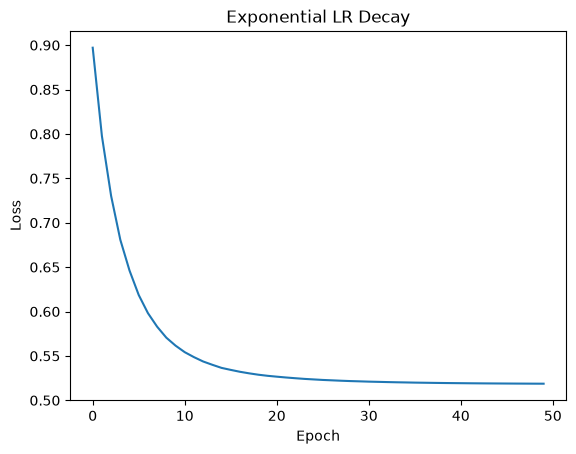

In [57]:
plt.plot(
decay_history.history["loss"]
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Exponential LR Decay")

plt.show()

In [58]:
# Compare Optimizers
optimizers = [
    "adam",
    "rmsprop",
    "nadam"
]


optimizer_results={}


for opt in optimizers:


    model = Sequential([


        Dense(
            16,
            activation="relu",
            input_shape=(X_train_standard.shape[1],)
        ),


        Dense(
            8,
            activation="relu"
        ),


        Dense(
            1,
            activation="sigmoid"
        )

    ])


    model.compile(

        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]

    )


    h=model.fit(

        X_train_standard,
        y_train,
        epochs=30,
        verbose=0

    )


    optimizer_results[opt]=[

        h.history["accuracy"][-1],
        h.history["loss"][-1]

    ]


optimizer_results

{'adam': [0.7982142567634583, 0.4925844371318817],
 'rmsprop': [0.7982142567634583, 0.4928930699825287],
 'nadam': [0.7982142567634583, 0.4912184178829193]}

In [59]:
# Apply Gradient Clipping
from tensorflow.keras.optimizers import Adam

In [60]:
clip_optimizer = Adam(
    clipnorm=1.0
)


clip_model = Sequential([


Dense(
16,
activation="relu",
input_shape=(X_train_standard.shape[1],)
),


Dense(
8,
activation="relu"
),


Dense(
1,
activation="sigmoid"
)

])


clip_model.compile(

optimizer=clip_optimizer,
loss="binary_crossentropy",
metrics=["accuracy"]

)


clip_model.fit(

X_train_standard,
y_train,
epochs=50,
validation_data=(X_val_standard,y_val)

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3946 - loss: 0.8410 - val_accuracy: 0.4833 - val_loss: 0.7844
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5054 - loss: 0.7350 - val_accuracy: 0.5667 - val_loss: 0.7044
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6429 - loss: 0.6634 - val_accuracy: 0.7167 - val_loss: 0.6502
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7464 - loss: 0.6174 - val_accuracy: 0.7250 - val_loss: 0.6075
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7589 - loss: 0.5841 - val_accuracy: 0.7583 - val_loss: 0.5772
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7732 - loss: 0.5616 - val_accuracy: 0.7750 - val_loss: 0.5550
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7929 - loss: 0.5450 - val_accuracy: 0.7833 - val_loss: 0.5403
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7982 - loss: 0.5336 - val_accuracy: 0.7917 - v

In [61]:
# Save only the best-performing model using ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint

In [62]:
checkpoint = ModelCheckpoint(

    "best_ann_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

In [63]:
checkpoint_model = create_ann()


checkpoint_history = checkpoint_model.fit(

    X_train_standard,

    y_train,

    epochs=50,

    validation_data=(X_val_standard, y_val),

    callbacks=[checkpoint]

)

Epoch 1/50
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.5605
Epoch 1: val_accuracy improved from None to 0.80000, saving model to best_ann_model.keras

Epoch 1: finished saving model to best_ann_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7982 - loss: 0.5578 - val_accuracy: 0.8000 - val_loss: 0.5578
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7982 - loss: 0.5404 
Epoch 2: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7982 - loss: 0.5404 - val_accuracy: 0.8000 - val_loss: 0.5455
Epoch 3/50
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7924 - loss: 0.5313 
Epoch 3: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7982 - loss: 0.5269 - val_accuracy: 0.8000 - val_loss: 0.5365
Epoch 4/50
13/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8005 - loss: 0.5254  
Epoch 4: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━

In [64]:
best_model = tf.keras.models.load_model(
    "best_ann_model.keras"
)


best_model.evaluate(
    X_test_standard,
    y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8000 - loss: 0.5365 


[0.5365408062934875, 0.800000011920929]

In [65]:
# Log Training with TensorBoard
from tensorflow.keras.callbacks import TensorBoard
import datetime

In [66]:
# Create TensorBoard Callback
log_folder = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")


tensorboard = TensorBoard(

    log_dir=log_folder,

    histogram_freq=1

)

In [67]:
# Train
! pip install tensorboard
tb_model = create_ann()


tb_model.fit(

    X_train_standard,

    y_train,

    epochs=30,

    validation_data=(X_val_standard,y_val),

    callbacks=[tensorboard]

)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4161 - loss: 0.7236 - val_accuracy: 0.5500 - val_loss: 0.6818
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6196 - loss: 0.6703 - val_accuracy: 0.6750 - val_loss: 0.6414
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6929 - loss: 0.6302 - val_accuracy: 0.7417 - val_loss: 0.6085
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7714 - loss: 0.5991 - val_accuracy: 0.8000 - val_loss: 0.5828
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7911 - loss: 0.5750 - val_accuracy: 0.8000 - val_loss: 0.5643
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7982 - loss: 0.5564 - val_accuracy: 0.8000 - val_loss: 0.5516
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7982 - loss: 0.5423 - val_accuracy: 0.8000 - val_loss: 0.5411
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7982 - loss: 0.5312 - val_accuracy: 0.8000 - v

In [68]:
from sklearn.model_selection import KFold

In [69]:
# Create Age_Bucket again

df["Age_Bucket"] = pd.cut(

    df["Age"],

    bins=[18,25,35,45,60],

    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46+"
    ]
)

In [70]:
kfold = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


scores = []


for train_index, test_index in kfold.split(X):


    X_train_cv = X.iloc[train_index]

    X_test_cv = X.iloc[test_index]


    y_train_cv = y.iloc[train_index]

    y_test_cv = y.iloc[test_index]


    scaler = StandardScaler()


    X_train_cv = scaler.fit_transform(
        X_train_cv
    )


    X_test_cv = scaler.transform(
        X_test_cv
    )


    model=create_ann()


    model.fit(

        X_train_cv,

        y_train_cv,

        epochs=30,

        verbose=0

    )


    loss,acc=model.evaluate(

        X_test_cv,

        y_test_cv,

        verbose=0

    )


    scores.append(acc)


print(scores)

print(
"Mean Accuracy:",
np.mean(scores)
)


print(
"STD:",
np.std(scores)
)

[0.800000011920929, 0.78125, 0.8374999761581421, 0.8187500238418579, 0.7562500238418579]
Mean Accuracy: 0.7987500071525574
STD: 0.028339449921183438


In [71]:
# Build Ensemble of ANNs
ensemble_predictions=[]


for seed in [1,2,3]:


    tf.random.set_seed(seed)


    model=create_ann()


    model.fit(

        X_train_standard,

        y_train,

        epochs=30,

        verbose=0

    )


    pred=model.predict(
        X_test_standard
    )


    ensemble_predictions.append(
        pred
    )

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/stepWARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002609F64E660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [72]:
# Majority Voting
average_prediction = np.mean(

    ensemble_predictions,

    axis=0

)


final_prediction = (

average_prediction > 0.5

).astype(int)


accuracy_score(

    y_test,

    final_prediction

)

0.8

In [73]:
# Write Custom Callback
class ConfidenceLogger(
    tf.keras.callbacks.Callback
):


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):


        if epoch % 10 == 0:


            prediction = self.model.predict(

                X_test_standard,

                verbose=0

            )


            print(

            "Epoch:",epoch,

            "Average Confidence:",

            np.mean(prediction)

            )

In [74]:
# Use Callback
callback_model=create_ann()


callback_model.fit(

    X_train_standard,

    y_train,

    epochs=50,

    callbacks=[ConfidenceLogger()]

)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7946 - loss: 0.5479Epoch: 0 Average Confidence: 0.26741558
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7946 - loss: 0.5479
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5340
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7982 - loss: 0.5256
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5193
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7982 - loss: 0.5144
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7982 - loss: 0.5105
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7982 - loss: 0.5074
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7982 - loss: 0.5048
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7982 - loss: 0.5028
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7982 - loss: 0.5010
Epoch 11/50
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [75]:
# Generate Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns


# Prediction

y_pred_prob = best_model.predict(
    X_test_standard
)


y_pred = (
    y_pred_prob > 0.5
).astype(int)


# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)


# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[96  0]
 [24  0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        96
           1       0.00      0.00      0.00        24

    accuracy                           0.80       120
   macro avg       0.40      0.50      0.44       120
weighted avg       0.64      0.80      0.71       120



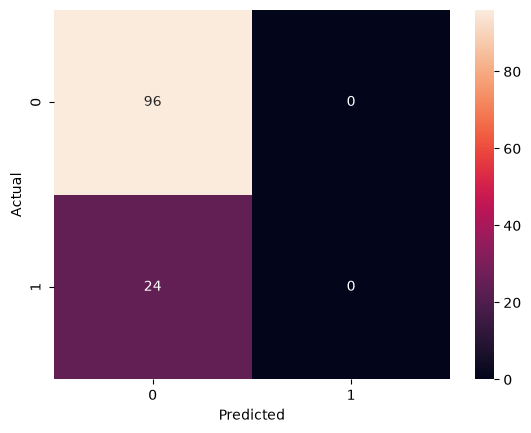

In [76]:
# Plot Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [77]:
# Plot ROC Curve and Calculate AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [78]:
fpr, tpr, threshold = roc_curve(

    y_test,

    y_pred_prob

)


auc_score = roc_auc_score(

    y_test,

    y_pred_prob

)


print(
"ROC AUC Score:",
auc_score
)

ROC AUC Score: 0.44921874999999994


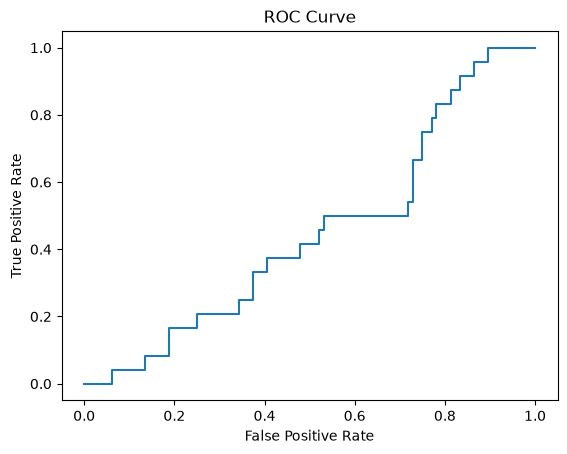

In [79]:
plt.plot(
    fpr,
    tpr
)


plt.xlabel(
"False Positive Rate"
)


plt.ylabel(
"True Positive Rate"
)


plt.title(
"ROC Curve"
)


plt.show()

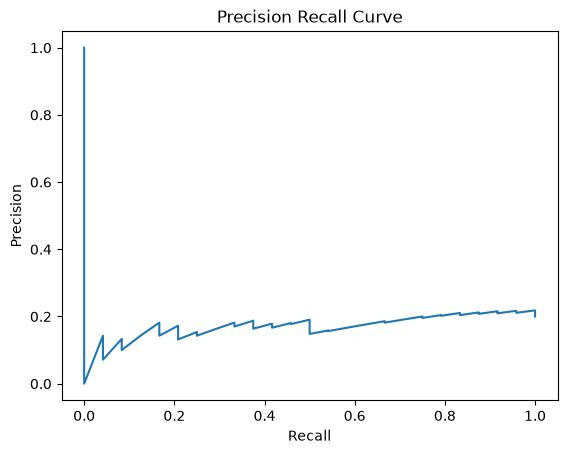

In [80]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(

    y_test,

    y_pred_prob

)


plt.plot(
    recall,
    precision
)


plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
"Precision Recall Curve"
)

plt.show()

In [81]:
# Feature Importance using Permutation Importance
!pip install eli5


   -------- ------------------------------- 1/5 [jinja2]
   -------- ------------------------------- 1/5 [jinja2]
   ---------------- ----------------------- 2/5 [graphviz]
   ------------------------ --------------- 3/5 [attrs]
   -------------------------------- ------- 4/5 [eli5]
   -------------------------------- ------- 4/5 [eli5]
   ---------------------------------------- 5/5 [eli5]



In [82]:
from sklearn.inspection import permutation_importance


def ann_score(X_data,y_data):

    pred = best_model.predict(
        X_data
    )

    pred = (
        pred > 0.5
    ).astype(int)


    return accuracy_score(
        y_data,
        pred
    )

In [83]:
baseline = ann_score(
    X_test_standard,
    y_test
)


importance=[]


for i in range(
    X_test_standard.shape[1]
):

    X_copy = X_test_standard.copy()

    np.random.shuffle(
        X_copy[:,i]
    )


    score = ann_score(
        X_copy,
        y_test
    )


    importance.append(
        baseline-score
    )


pd.DataFrame({

"Feature":X.columns,

"Importance":importance

}).sort_values(

"Importance",

ascending=False

)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Feature,Importance
0,Age,0.0
1,Salary,0.0
2,Experience,0.0
3,Salary_per_Experience,0.0
4,Age_Salary_Interaction,0.0
5,Age_Bucket_18-25,0.0
6,Age_Bucket_26-35,0.0
7,Age_Bucket_36-45,0.0
8,Age_Bucket_46+,0.0


In [84]:
# Explain Predictions using SHAP
!pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 334.5 kB/s  0:00:01
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   --------------- ------------------------ 262.1/676.6 kB ? eta -:--:--
   --------------- ------------------------ 262.1/676.6 kB ? eta -:--:--
   --------------- ------------------------ 262.1/676.6 k

In [85]:
import shap

ExactExplainer explainer: 51it [00:27,  1.79it/s]                        


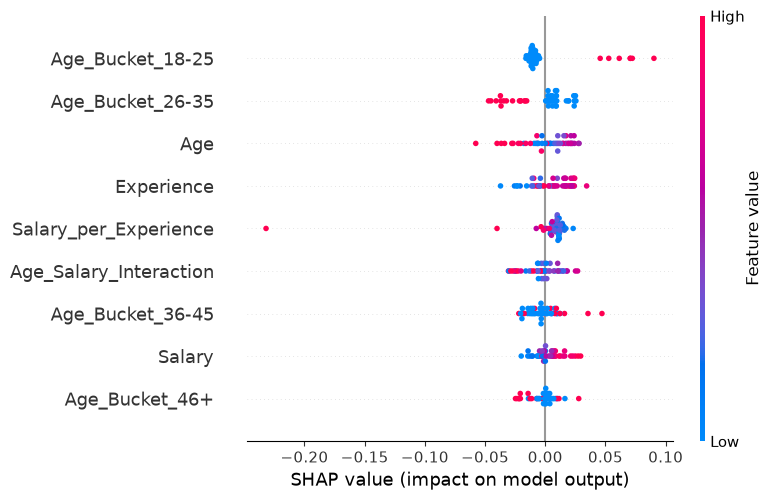

In [86]:
explainer = shap.Explainer(

    best_model,

    X_train_standard

)


shap_values = explainer(

    X_test_standard[:50]

)


shap.summary_plot(

    shap_values,

    X_test_standard[:50],

    feature_names=X.columns

)

In [87]:
shap.plots.waterfall(

    shap_values[0]

)

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
# Error Analysis on Misclassified Customers
errors = X_test[

    y_test.values != 
    y_pred.flatten()

]


errors.head()

In [ ]:
print(
"Total Wrong Predictions:",
len(errors)
)

In [ ]:
errors.describe()

In [ ]:
# Test Robustness to Input Noise
# Original accuracy

original_loss, original_accuracy = best_model.evaluate(

    X_test_standard,

    y_test,

    verbose=0

)


print(
"Original Accuracy:",
original_accuracy
)

In [ ]:
# Add Gaussian noise

noise = np.random.normal(

    0,

    0.1,

    X_test_standard.shape

)


X_test_noise = (

    X_test_standard + noise

)


noise_loss, noise_accuracy = best_model.evaluate(

    X_test_noise,

    y_test,

    verbose=0

)


print(
"Noise Accuracy:",
noise_accuracy
)


print(
"Accuracy Drop:",
original_accuracy-noise_accuracy
)

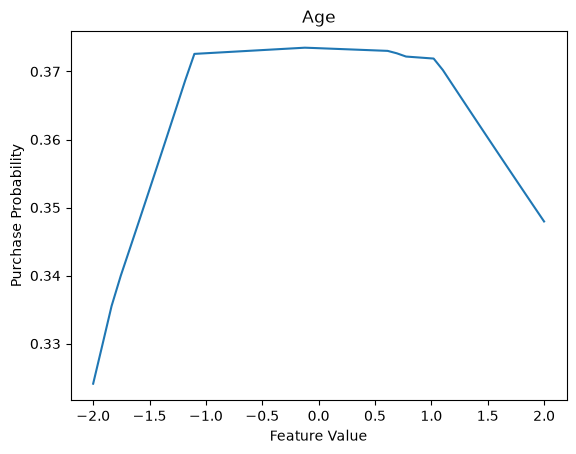

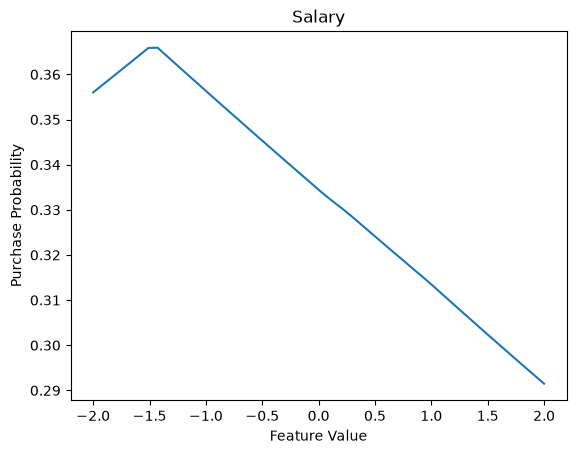

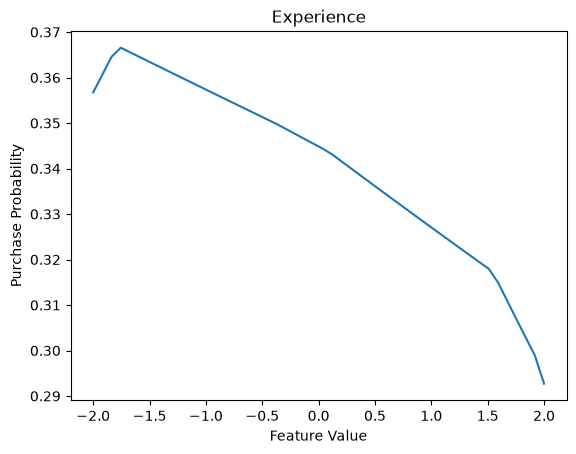

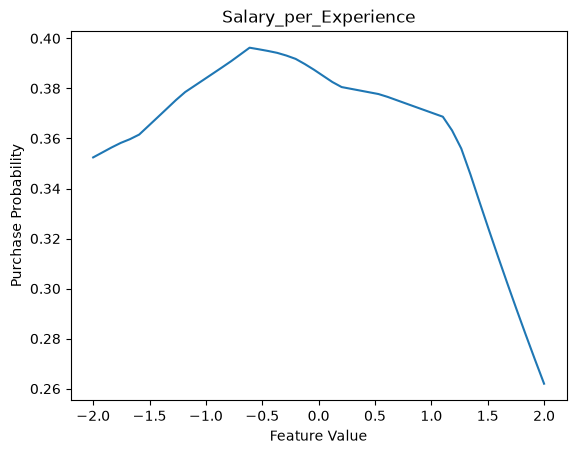

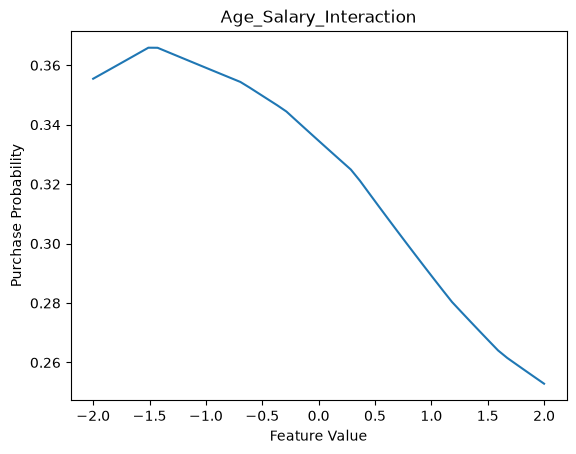

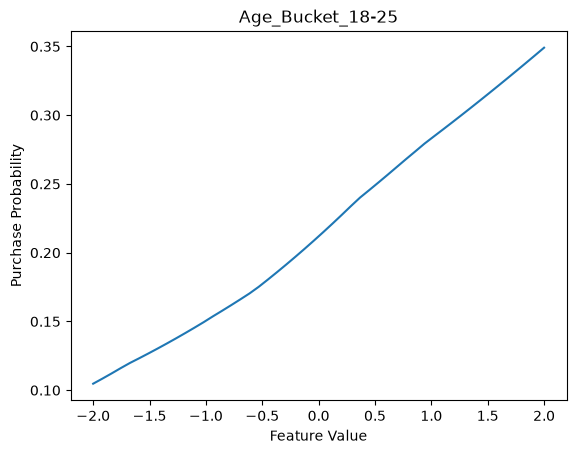

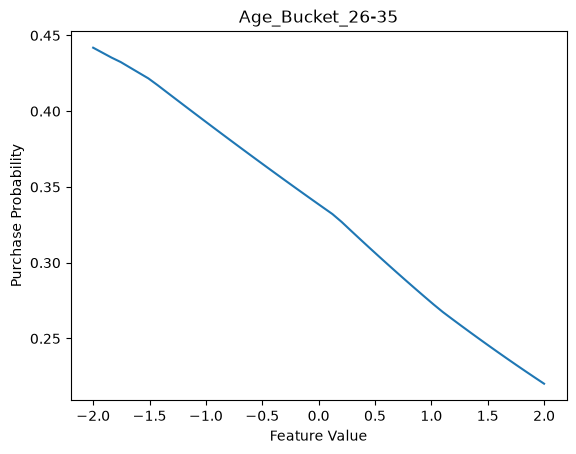

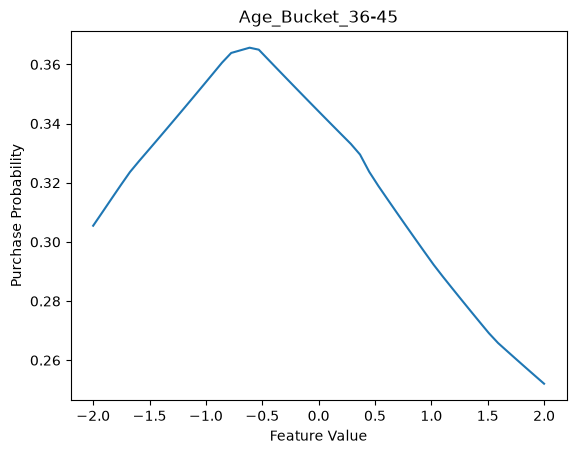

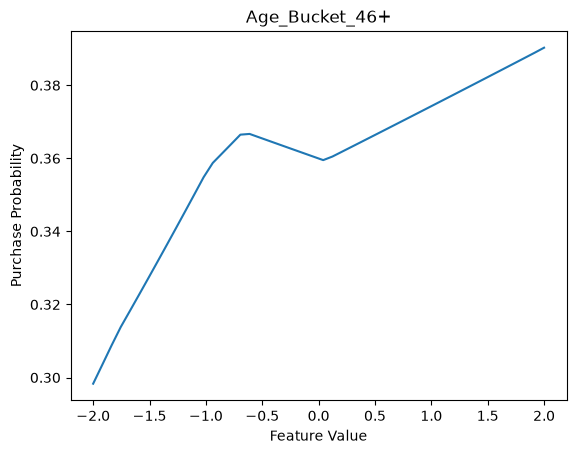

In [88]:
# One-at-a-Time Sensitivity Analysis
feature_names = X.columns


for feature_index in range(
    X_test_standard.shape[1]
):

    sample = X_test_standard[0].copy()


    values = np.linspace(
        -2,
        2,
        50
    )


    predictions=[]


    for value in values:


        sample_copy = sample.copy()


        sample_copy[feature_index]=value


        pred = best_model.predict(

            sample_copy.reshape(1,-1),

            verbose=0

        )


        predictions.append(
            pred[0][0]
        )


    plt.plot(
        values,
        predictions
    )


    plt.title(
        feature_names[feature_index]
    )


    plt.xlabel(
        "Feature Value"
    )


    plt.ylabel(
        "Purchase Probability"
    )


    plt.show()

In [89]:
# Bootstrapped Retraining
from sklearn.utils import resample


bootstrap_scores=[]


for i in range(10):


    X_sample, y_sample = resample(

        X_train_standard,

        y_train,

        random_state=i

    )


    model=create_ann(
        X_train_standard.shape[1]
    )


    model.fit(

        X_sample,

        y_sample,

        epochs=20,

        verbose=0

    )


    loss,acc=model.evaluate(

        X_test_standard,

        y_test,

        verbose=0

    )


    bootstrap_scores.append(acc)



print(
"Mean Accuracy:",
np.mean(bootstrap_scores)
)


print(
"STD:",
np.std(bootstrap_scores)
)

TypeError: create_ann() takes 0 positional arguments but 1 was given

In [ ]:
# Convert Model to TensorFlow Lite
import os


# Save keras model

best_model.save(
    "customer_ann.keras"
)


# Convert

converter = tf.lite.TFLiteConverter.from_keras_model(

    best_model

)


tflite_model = converter.convert()


with open(
    "customer_ann.tflite",
    "wb"
) as f:

    f.write(
        tflite_model
    )

In [ ]:
keras_size = os.path.getsize(

    "customer_ann.keras"

)


lite_size = os.path.getsize(

    "customer_ann.tflite"

)


print(
"Keras Size:",
keras_size
)


print(
"TFLite Size:",
lite_size
)

In [90]:
# Prediction Function using JSON Input
def predict_customer(data):


    df_input = pd.DataFrame(
        [data]
    )


    scaled = scaler.transform(
        df_input
    )


    probability = best_model.predict(
        scaled
    )[0][0]


    prediction = int(
        probability > 0.5
    )


    return {

        "Purchase Probability":
        float(probability),


        "Prediction":
        prediction

    }

In [ ]:
customer = {

"Age":30,

"Salary":80000,

"Experience":5

}


predict_customer(customer)

In [92]:
# Multi Output Learning ANN
df["Customer_Lifetime_Value"] = (

    df["Salary"] * 0.2

    +

    df["Experience"] * 1000

)

In [93]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


input_layer = Input(

shape=(X_train_standard.shape[1],)

)


hidden = Dense(

32,

activation="relu"

)(input_layer)


hidden = Dense(

16,

activation="relu"

)(hidden)


purchase_output = Dense(

1,

activation="sigmoid",

name="purchase"

)(hidden)


value_output = Dense(

1,

activation="linear",

name="value"

)(hidden)



multi_model = Model(

input_layer,

[
purchase_output,
value_output
]

)


multi_model.compile(

optimizer="adam",

loss=[

"binary_crossentropy",

"mse"

]

)


multi_model.summary()

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 32)        │        320 │ input_layer_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_99 (Dense)    │ (None, 16)        │        528 │ dense_98[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ purchase (Dense)    │ (None, 1)         │         17 │ dense_99[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         17 │ dense_99[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 882 (3.45 KB)

 Trainable params: 882 (3.45 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
# Production Style ANN Pipeline (Capstone)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization


final_model = Sequential([


Dense(
64,
activation="relu",
input_shape=(X_train_standard.shape[1],)
),


BatchNormalization(),


Dropout(0.2),


Dense(
32,
activation="relu"
),


BatchNormalization(),


Dropout(0.2),


Dense(
16,
activation="relu"
),


Dense(
1,
activation="sigmoid"
)

])


final_model.compile(

optimizer="adam",

loss="binary_crossentropy",

metrics=["accuracy"]

)

In [95]:
final_history = final_model.fit(

X_train_standard,

y_train,

epochs=100,

validation_data=(X_val_standard,y_val),

callbacks=[

early_stop,

checkpoint,

lr_reduce

]

)

Epoch 1/100
12/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3464 - loss: 1.0065 
Epoch 1: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3786 - loss: 0.9484 - val_accuracy: 0.3167 - val_loss: 0.7288 - learning_rate: 0.0010
Epoch 2/100
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5331 - loss: 0.7448 
Epoch 2: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5321 - loss: 0.7437 - val_accuracy: 0.7500 - val_loss: 0.6508 - learning_rate: 0.0010
Epoch 3/100
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6920 - loss: 0.6165 
Epoch 3: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6875 - loss: 0.6168 - val_accuracy: 0.8000 - val_loss: 0.6059 - learning_rate: 0.0010
Epoch 4/100
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7148 - loss: 0.6079  
Epoch 4: val_accuracy did not improve from 0.80000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1

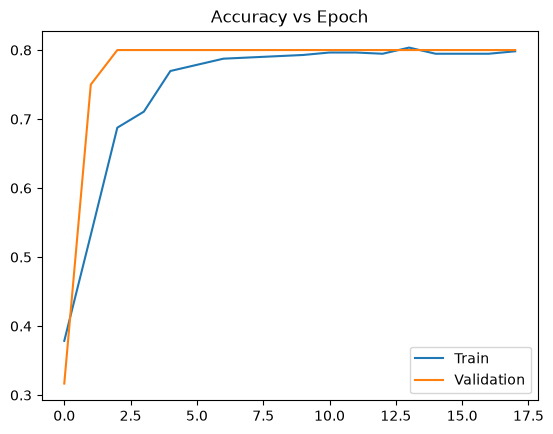

In [96]:
plt.plot(

final_history.history["accuracy"]

)


plt.plot(

final_history.history["val_accuracy"]

)


plt.title(
"Accuracy vs Epoch"
)


plt.legend(
[
"Train",
"Validation"
]
)


plt.show()

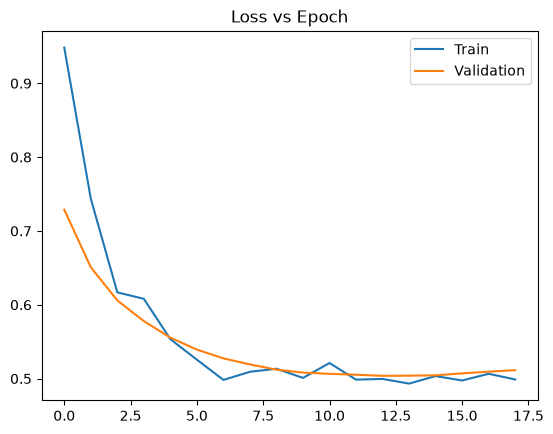

In [97]:
plt.plot(

final_history.history["loss"]

)


plt.plot(

final_history.history["val_loss"]

)


plt.title(
"Loss vs Epoch"
)


plt.legend(
[
"Train",
"Validation"
]
)


plt.show()